---
numbering: false
---

# 2.5. Least Squares

## The Modeling Recipe

We've now made several passes over the three-step modeling recipe, first introduced in [Chapter 1.3](../01_introduction_to_supervised_learning/03-absolute-loss.ipynb).

1. **Choose a model.**
2. **Choose a loss function.**
3. **Minimize average loss to find optimal parameters.**

Our very first pass through the recipe involved:
1. The constant model, $h(x_i) = w$.
2. Squared loss, $L_\text{sq}(y_i, h(x_i)) = (y_i - h(x_i))^2$.
3. The above two choices gave us average loss, or empirical risk, of $$R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2$$ which we showed is minimized by $w^* = \bar{y}$.

Then, in [Chapter 2.3](03-finding-optimal-parameters.ipynb), we considered:

1. The simple linear regression model, $h(x_i) = w_0 + w_1 x_i$.
2. Squared loss, $L_\text{sq}(y_i, h(x_i)) = (y_i - h(x_i))^2$.
3. The above two choices gave us average loss, or empirical risk, of $$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$ which we showed – using partial derivatives – is minimized by

$$w_1^* = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = r \frac{\sigma_y}{\sigma_x}, \qquad w_0^* = \bar{y} - w_1^* \bar{x}$$

Let's visualize both the best <span style="color:#d81b60; font-weight: bold;">constant model</span> and the best <span style="color:orange; font-weight: bold;">simple linear regression model</span> on the commute times dataset.

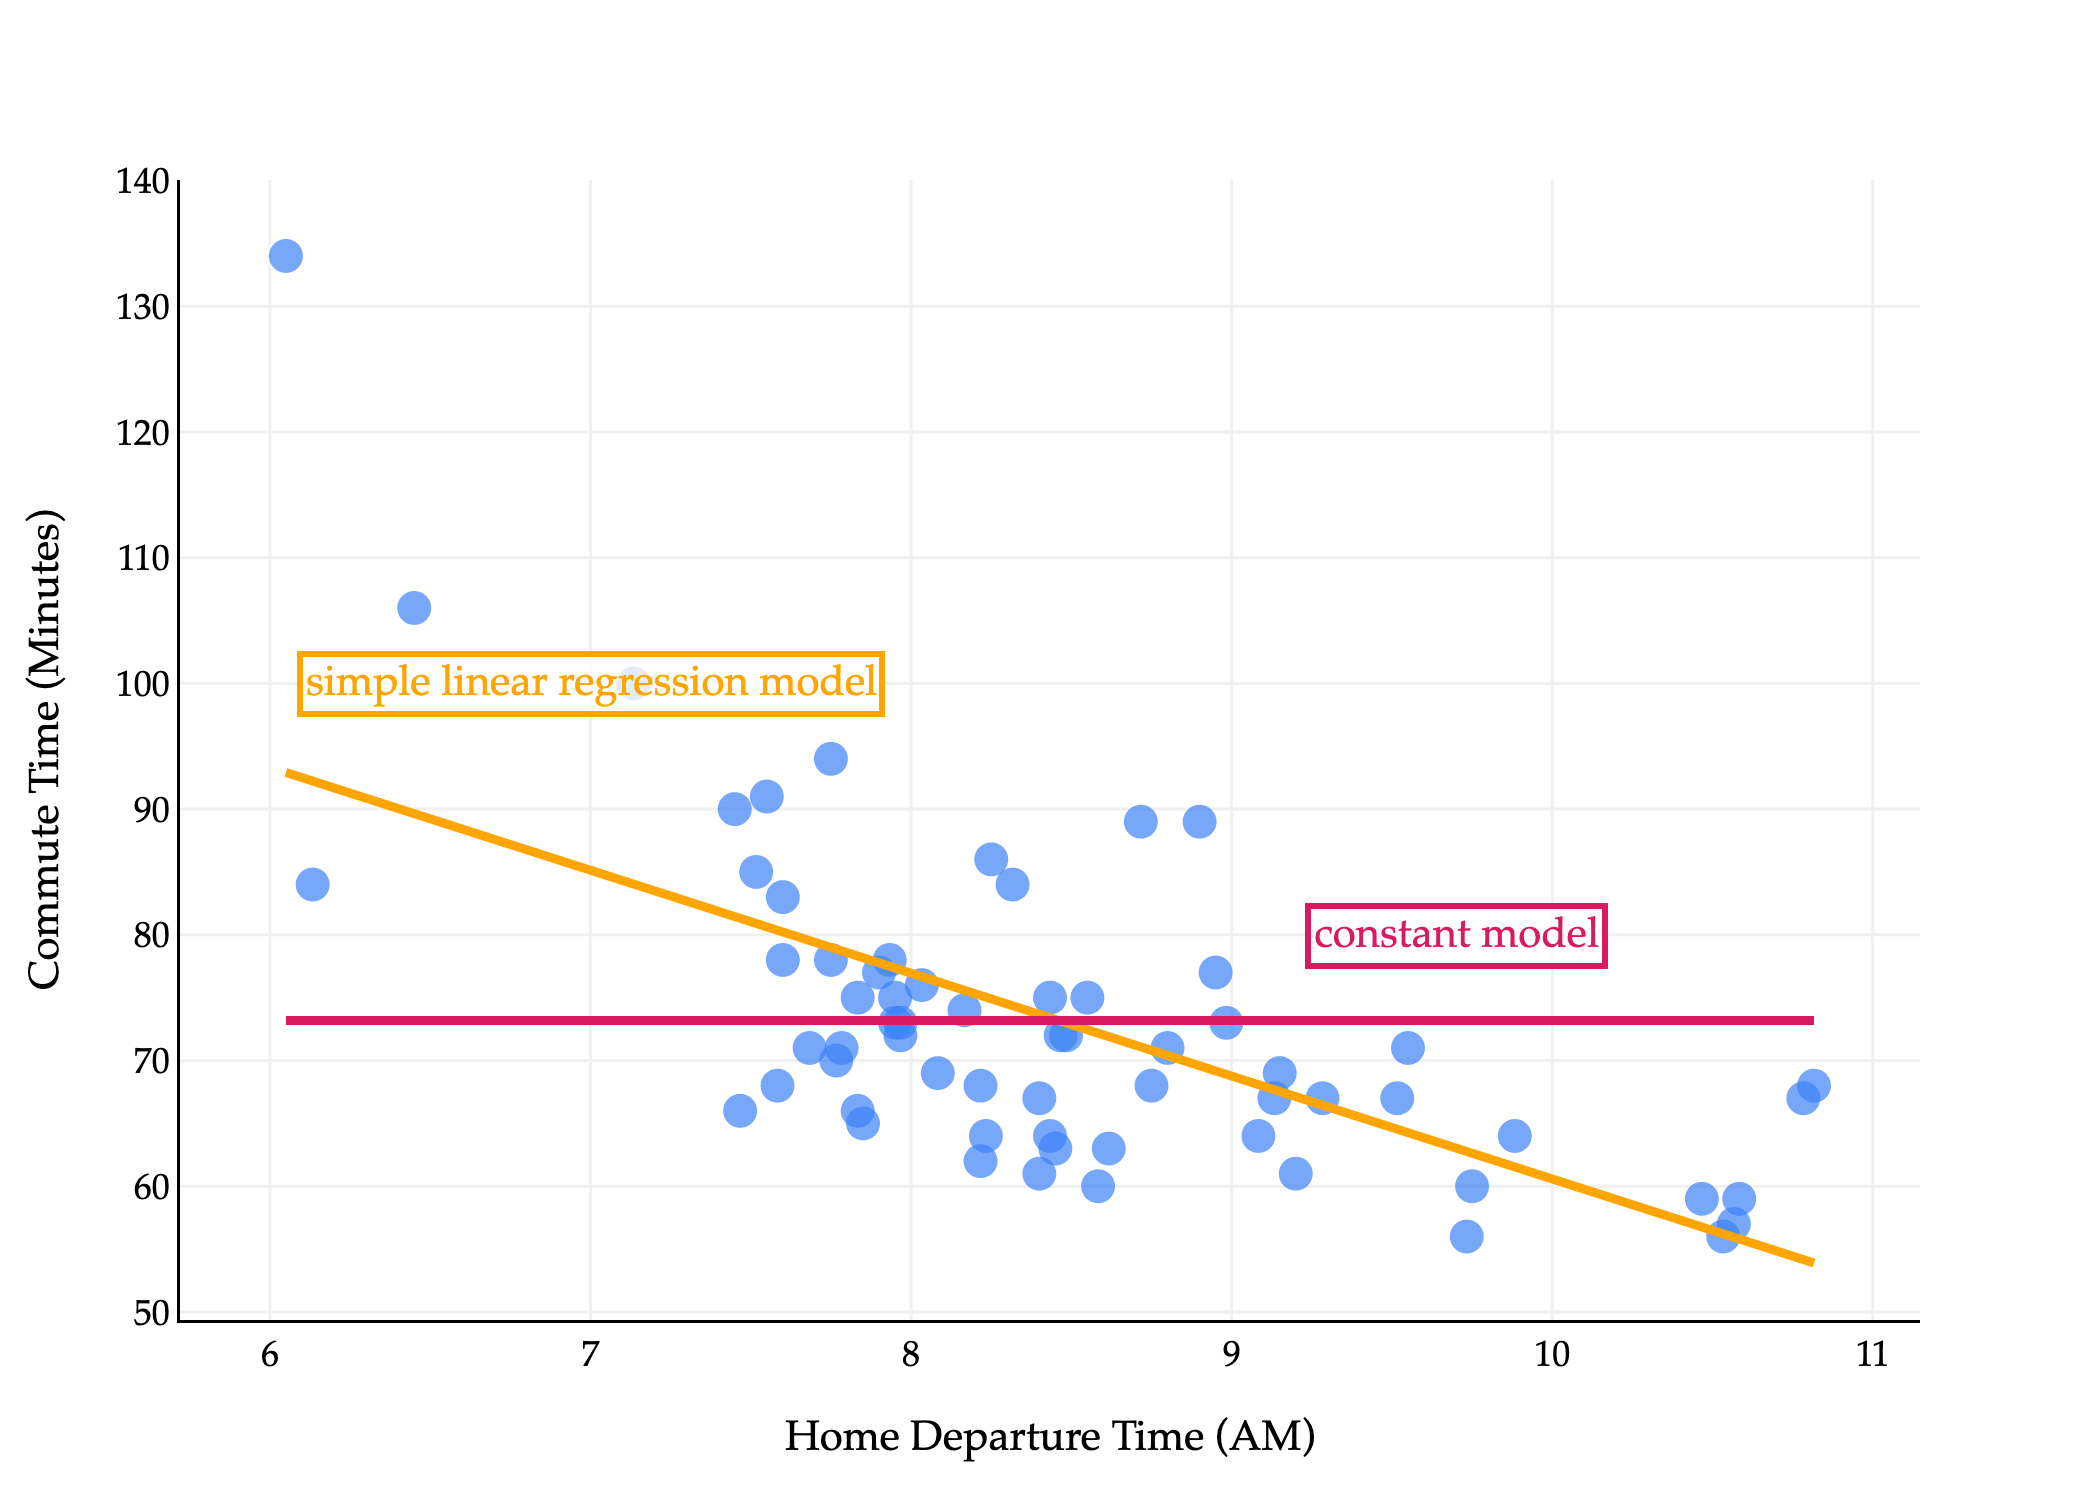

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('data/commute-times.csv')

# Compute means
x = df['departure_hour'].values
y = df['minutes'].values
x_bar = np.mean(x)
y_bar = np.mean(y)

# Compute slope (w1) and intercept (w0) using the closed-form solution
w1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
w0 = y_bar - w1 * x_bar

# Prepare regression line points
x_line = np.array([x.min(), x.max()])
y_line = w0 + w1 * x_line

# Create scatter plot
fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)

# Add regression line in orange
fig.add_traces(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='orange', width=3),
    name='Regression Line'
))

# Add horizontal line at y = mean(y), color #d81b60
fig.add_traces(go.Scatter(
    x=[x.min(), x.max()],
    y=[y_bar, y_bar],
    mode='lines',
    line=dict(color='#d81b60', width=3),
    name='Constant Model'
))

# Add annotation for simple linear regression (orange) at (10, 70)
fig.add_annotation(
    x=7,
    y=100,
    text="simple linear regression model",
    showarrow=False,
    font=dict(color='orange', size=14),
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='orange',
    borderwidth=2
)

# Add annotation for constant model (#d81b60) at (6, 70)
fig.add_annotation(
    x=9.7,
    y=80,
    text="constant model",
    showarrow=False,
    font=dict(color='#d81b60', size=14),
    bgcolor='rgba(255, 255, 255, 0.8)',
    bordercolor='#d81b60',
    borderwidth=2
)

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)
fig.show(renderer='png', scale=3)

:::{tip} Activity 1
:class: dropdown

What are the coordinates of the point of intersection of the two lines above?

:::

A fact we mentioned earlier – and you restated in Homework 1 – is that the mean squared error of the best constant model is the variance of the data. We can see this by substituting $w^* = \bar{y}$ into mean squared error:

$$R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - h)^2 \implies R_\text{sq}(\bar{y}) = \underbrace{\frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2}_{\text{variance of } y} = \sigma_y^2$$

This gives us a nice baseline from which to compare the performance of more sophisticated models. **If a model we create has a mean squared error that's higher than the variance of the data, we know we've done something wrong, because a constant model would be better!**

The mean squared error of the best simple linear regression model on the data is:

$$R_\text{sq}(w_0^*, w_1^*) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0^* + w_1^* x_i))^2$$

This formula alone isn't particularly enlightening, but it turns out this is equivalent to $\sigma_y^2 (1 - r^2)$, where $r$ is the correlation coefficient between $x$ and $y$. (The proof of this is an optional component of Homework 2.) 

This means that the best simple linear regression model **can't** perform worse than the best constant model. If $r = 0$, then the best simple linear regression model has a slope of 0, and is just the best constant model! Otherwise, the best simple linear regression model will have a non-zero slope, which is chosen to minimize mean squared error.

In this particular dataset:

$$\text{MSE of {\color{#d81b60}{best constant model}}} = \sigma_y^2 = 167.54 \text{ minutes}^2 \\ \text{MSE of {\color{orange}{best simple linear regression model}}} = \sigma_y^2 \underbrace{(1 - r^2)}_{\text{here, } r = -0.65} = 97.05 \text{ minutes}^2$$

In [ ]:
# Assume x and y are arrays containing 
# departure hours and commute times, respectively.
np.var(y, ddof=0)

167.535147928994

In [15]:
np.corrcoef(x, y)[0, 1]

-0.6486426165832004

In [13]:
np.var(y, ddof=0) * (1 - np.corrcoef(x, y)[0, 1]**2)

97.04687150819171

---

## Least Squares

**Least squares** is the general term for minimizing mean squared error – or equivalently, the sum of squared errors – to find optimal model parameters. Least squares appears quite frequently outside of machine learning contexts, too.

:::{tip} Activity 2
:class: dropdown
I glossed over something important above. I said that minimizing mean squared error is equivalent to minimizing the sum of squared errors.

Why is that true? Let's consider a particular example, of finding $w_0^*$ and $w_1^*$ for the simple linear regression model $h(x_i) = w_0 + w_1 x_i$.

Why are the $w_0^*$ and $w_1^*$ that minimize

$$R_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

the same as the $w_0^*$ and $w_1^*$ that minimize

$$S_\text{sq}(w_0, w_1) = \sum_{i=1}^n (y_i - (w_0 + w_1 x_i))^2$$

This idea was also reinforced in Lab 1, and in [Activity 3 of Appendix 2](../00_math_foundations/02-derivatives.ipynb#maxima-and-minima).

:::

For example, population ecologists use least squares to model the growth of populations (say, of an animal species) over time.

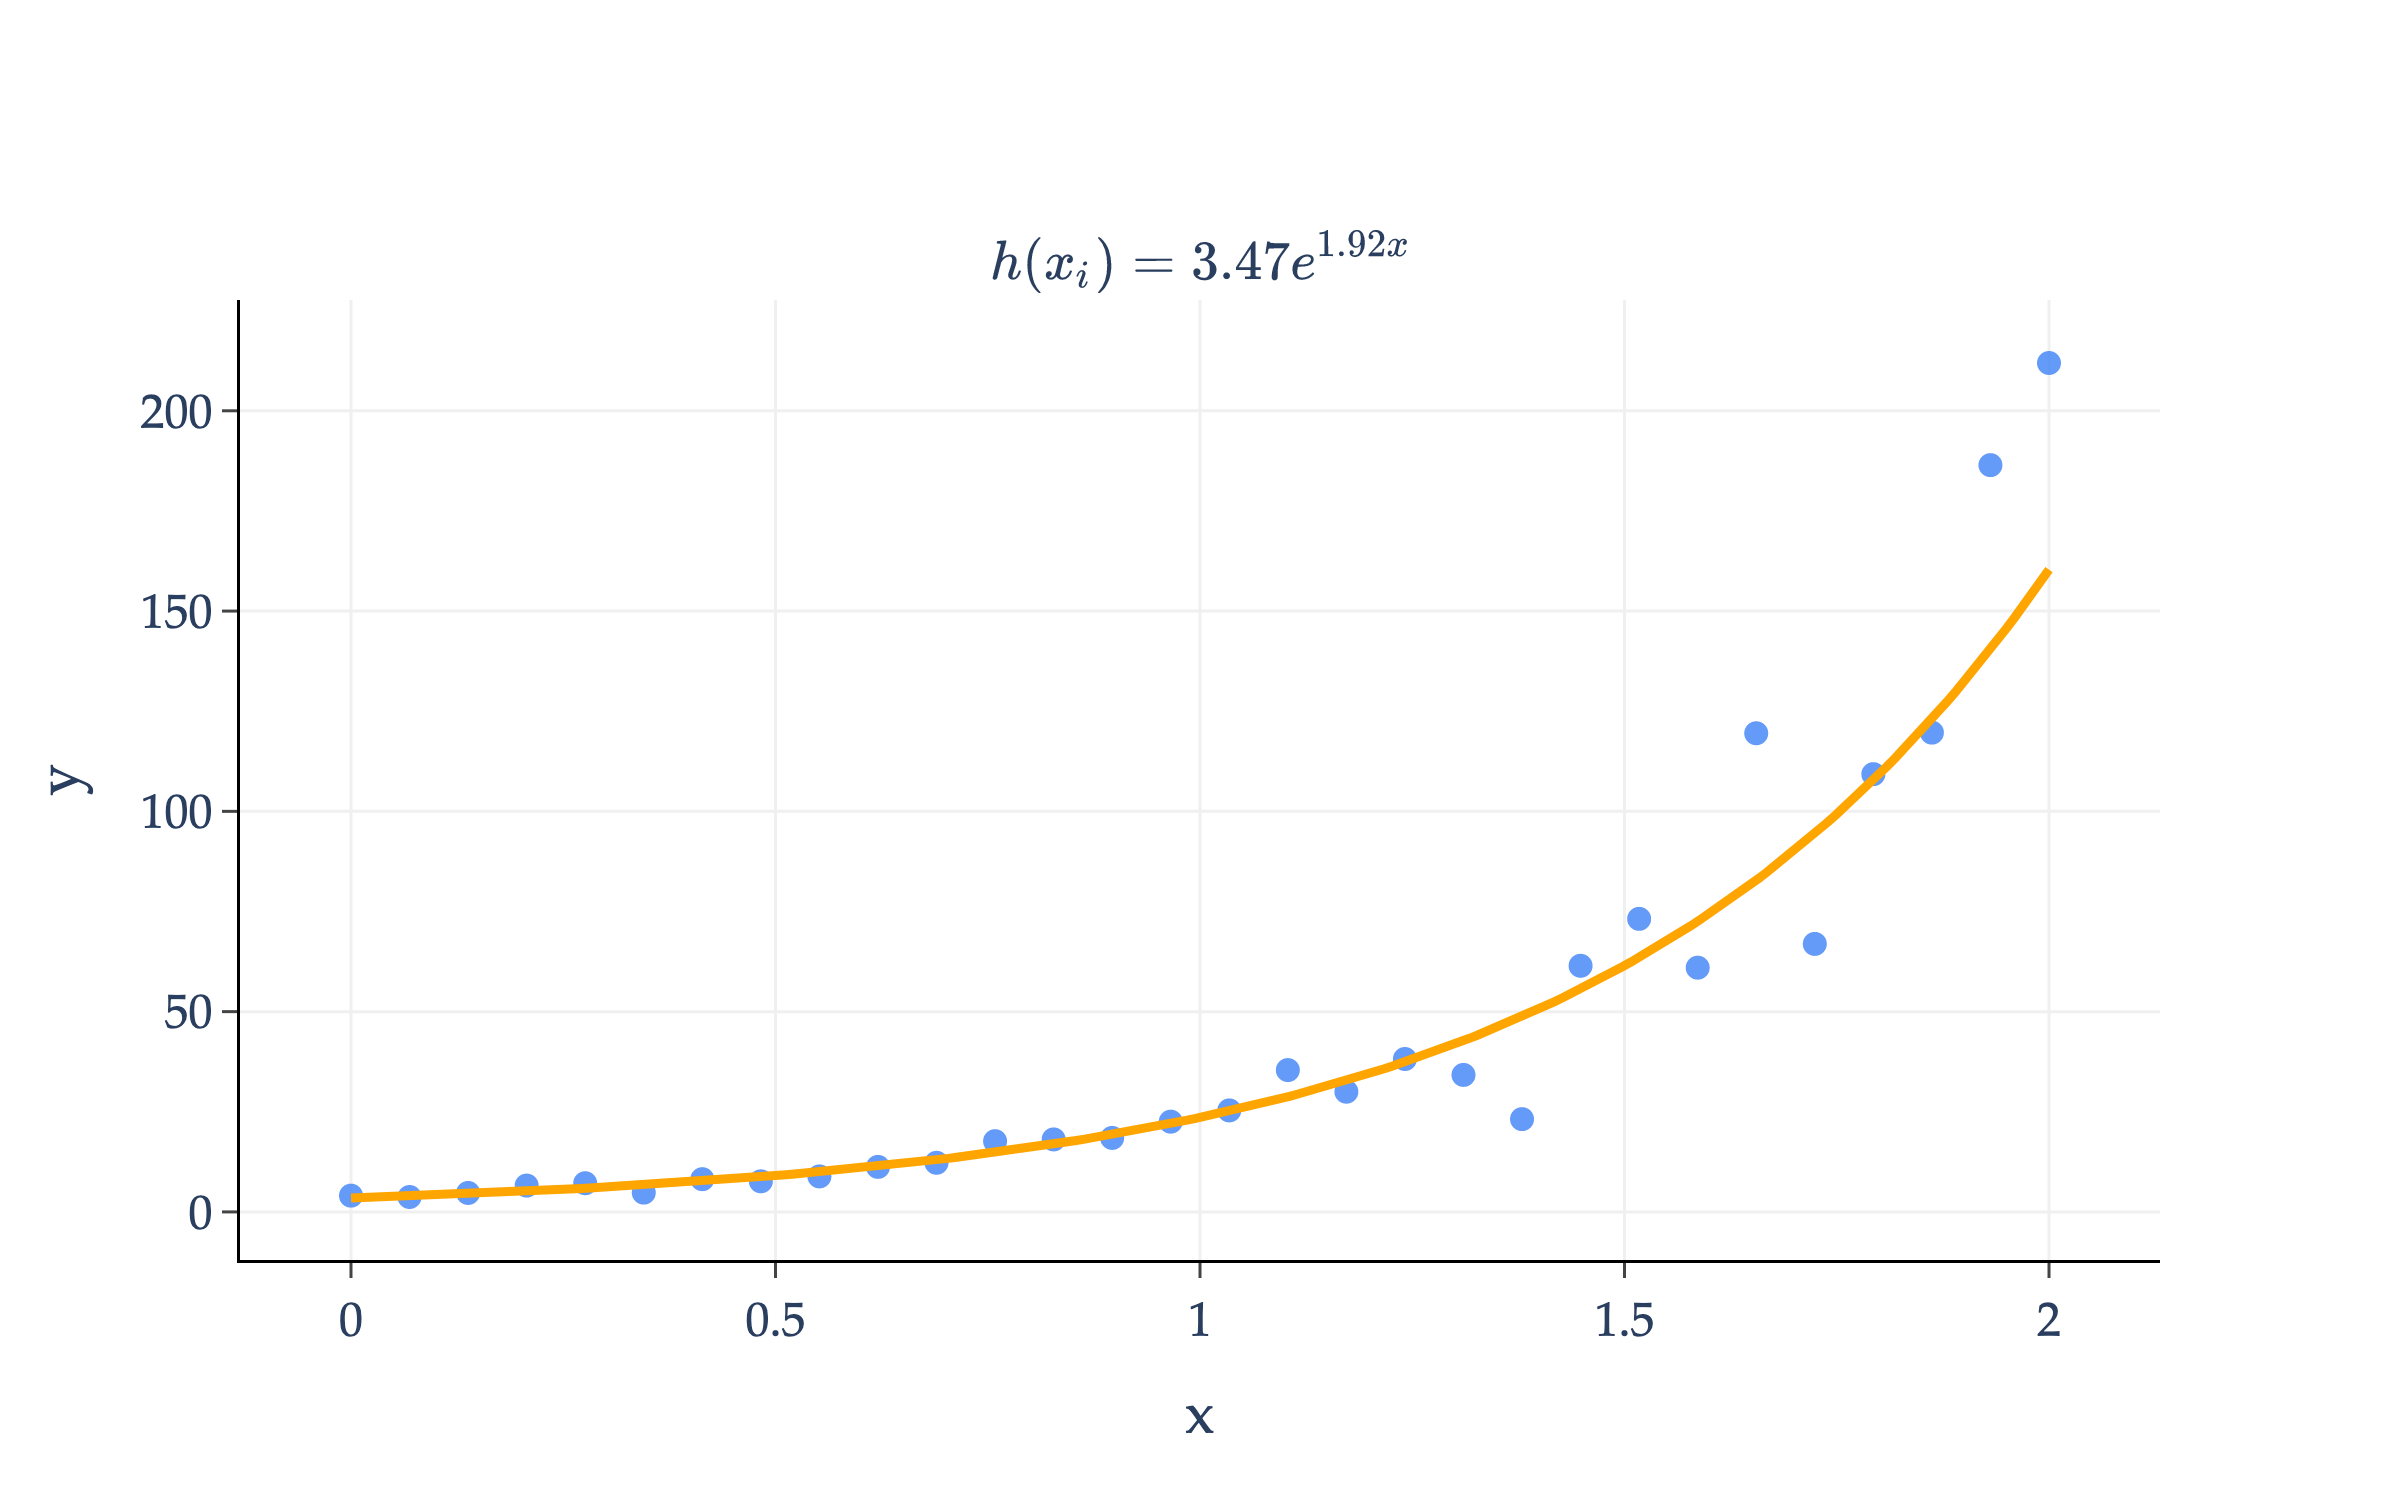

In [87]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import curve_fit

# Generate data
np.random.seed(0)
x = np.linspace(0, 2, 30)
y_true = 3 * np.exp(2 * x)
noise = np.random.normal(0, 0.2 * y_true, size=x.shape)
y = y_true + noise

# Define the model function
def exp_model(x, a, b):
    return a * np.exp(b * x)

# Fit the model to the data
z = np.log(y)
w1, w0 = np.polyfit(x, z, 1)
a_fit, b_fit = np.e ** w0, w1

# Prepare fitted curve
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = (np.e ** (w0)) * np.e ** (w1 * x_fit)#  * #exp_model(x_fit, a_fit, b_fit)

# Plot with plotly and custom style
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=y, mode='markers', name='Data',
    marker=dict(color='#3d81f6', size=8, opacity=0.8)
))
fig.add_trace(go.Scatter(
    x=x_fit, y=y_fit, mode='lines',
    name=f'Fit: y = {a_fit:.2f} e^{{{b_fit:.2f}x}}',
    line=dict(color='orange', width=3)
))
fig.update_layout(
    xaxis_title='x',
    yaxis_title='y',
    legend_title='Legend',
    width=800,
    height=500,
    font=dict(family='Palatino, serif', size=16),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    annotations=[
        dict(
            xref='paper', yref='paper',
            x=0.5, y=1.08, showarrow=False,
            text=fr'$$h(x_i) = {a_fit:.2f} e^{{{b_fit:.2f}x}}$$',
            font=dict(size=40, family='Palatino, serif'),
            xanchor='center'
        )
    ]
)
fig.update_xaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif')
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif'),
)
fig.show(renderer='png', scale=3)





The <span style="color:orange; font-weight: bold;">orange curve</span> above is of the form $h(x_i) = ae^{bx_i}$, where $a$ and $b$ are parameters. I've chosen the form $ae^{bx_i}$ because it's a good fit for the data; it's how we model exponential growth.

$a$ and $b$ **could** be chosen by minimizing mean squared error directly:

$$R_\text{sq}(a, b) = \frac{1}{n} \sum_{i=1}^n (y_i - ae^{bx_i})^2$$

If we wanted to minimize $R_\text{sq}(a, b)$, we'd need to take partial derivatives with respect to $a$ and $b$, set them to 0, and solve the resulting system of equations. However, the function $h(x_i) = ae^{bx_i}$ involves a parameter ($b$) in the exponent, which means the resulting partial derivatives of $R_\text{sq}$ will be complicated and the resulting system of equations will be challenging to solve. (Don't believe me? Try finding $\frac{\partial R_\text{sq}}{\partial b}$.)

In this particular case, there's a transformation we can apply to the data so that we can reduce the minimization problem to something we've seen before! Consider what happens if we take the logarithm of both sides of the equation $y_i \approx ae^{bx_i}$:

$$y_i \approx ae^{bx_i} \implies \log(y_i) \approx \log(a) + bx_i$$

I've written the $\approx$ symbol to remind us that $y_i$ is not exactly equal to $ae^{bx_i}$, but rather, the goal is to choose $a$ and $b$ so that $ae^{bx_i}$ is approximately equal to $y_i$, across all points $i$.

When we take the logarithm of each $y$-value in our dataset, the resulting plot looks like:

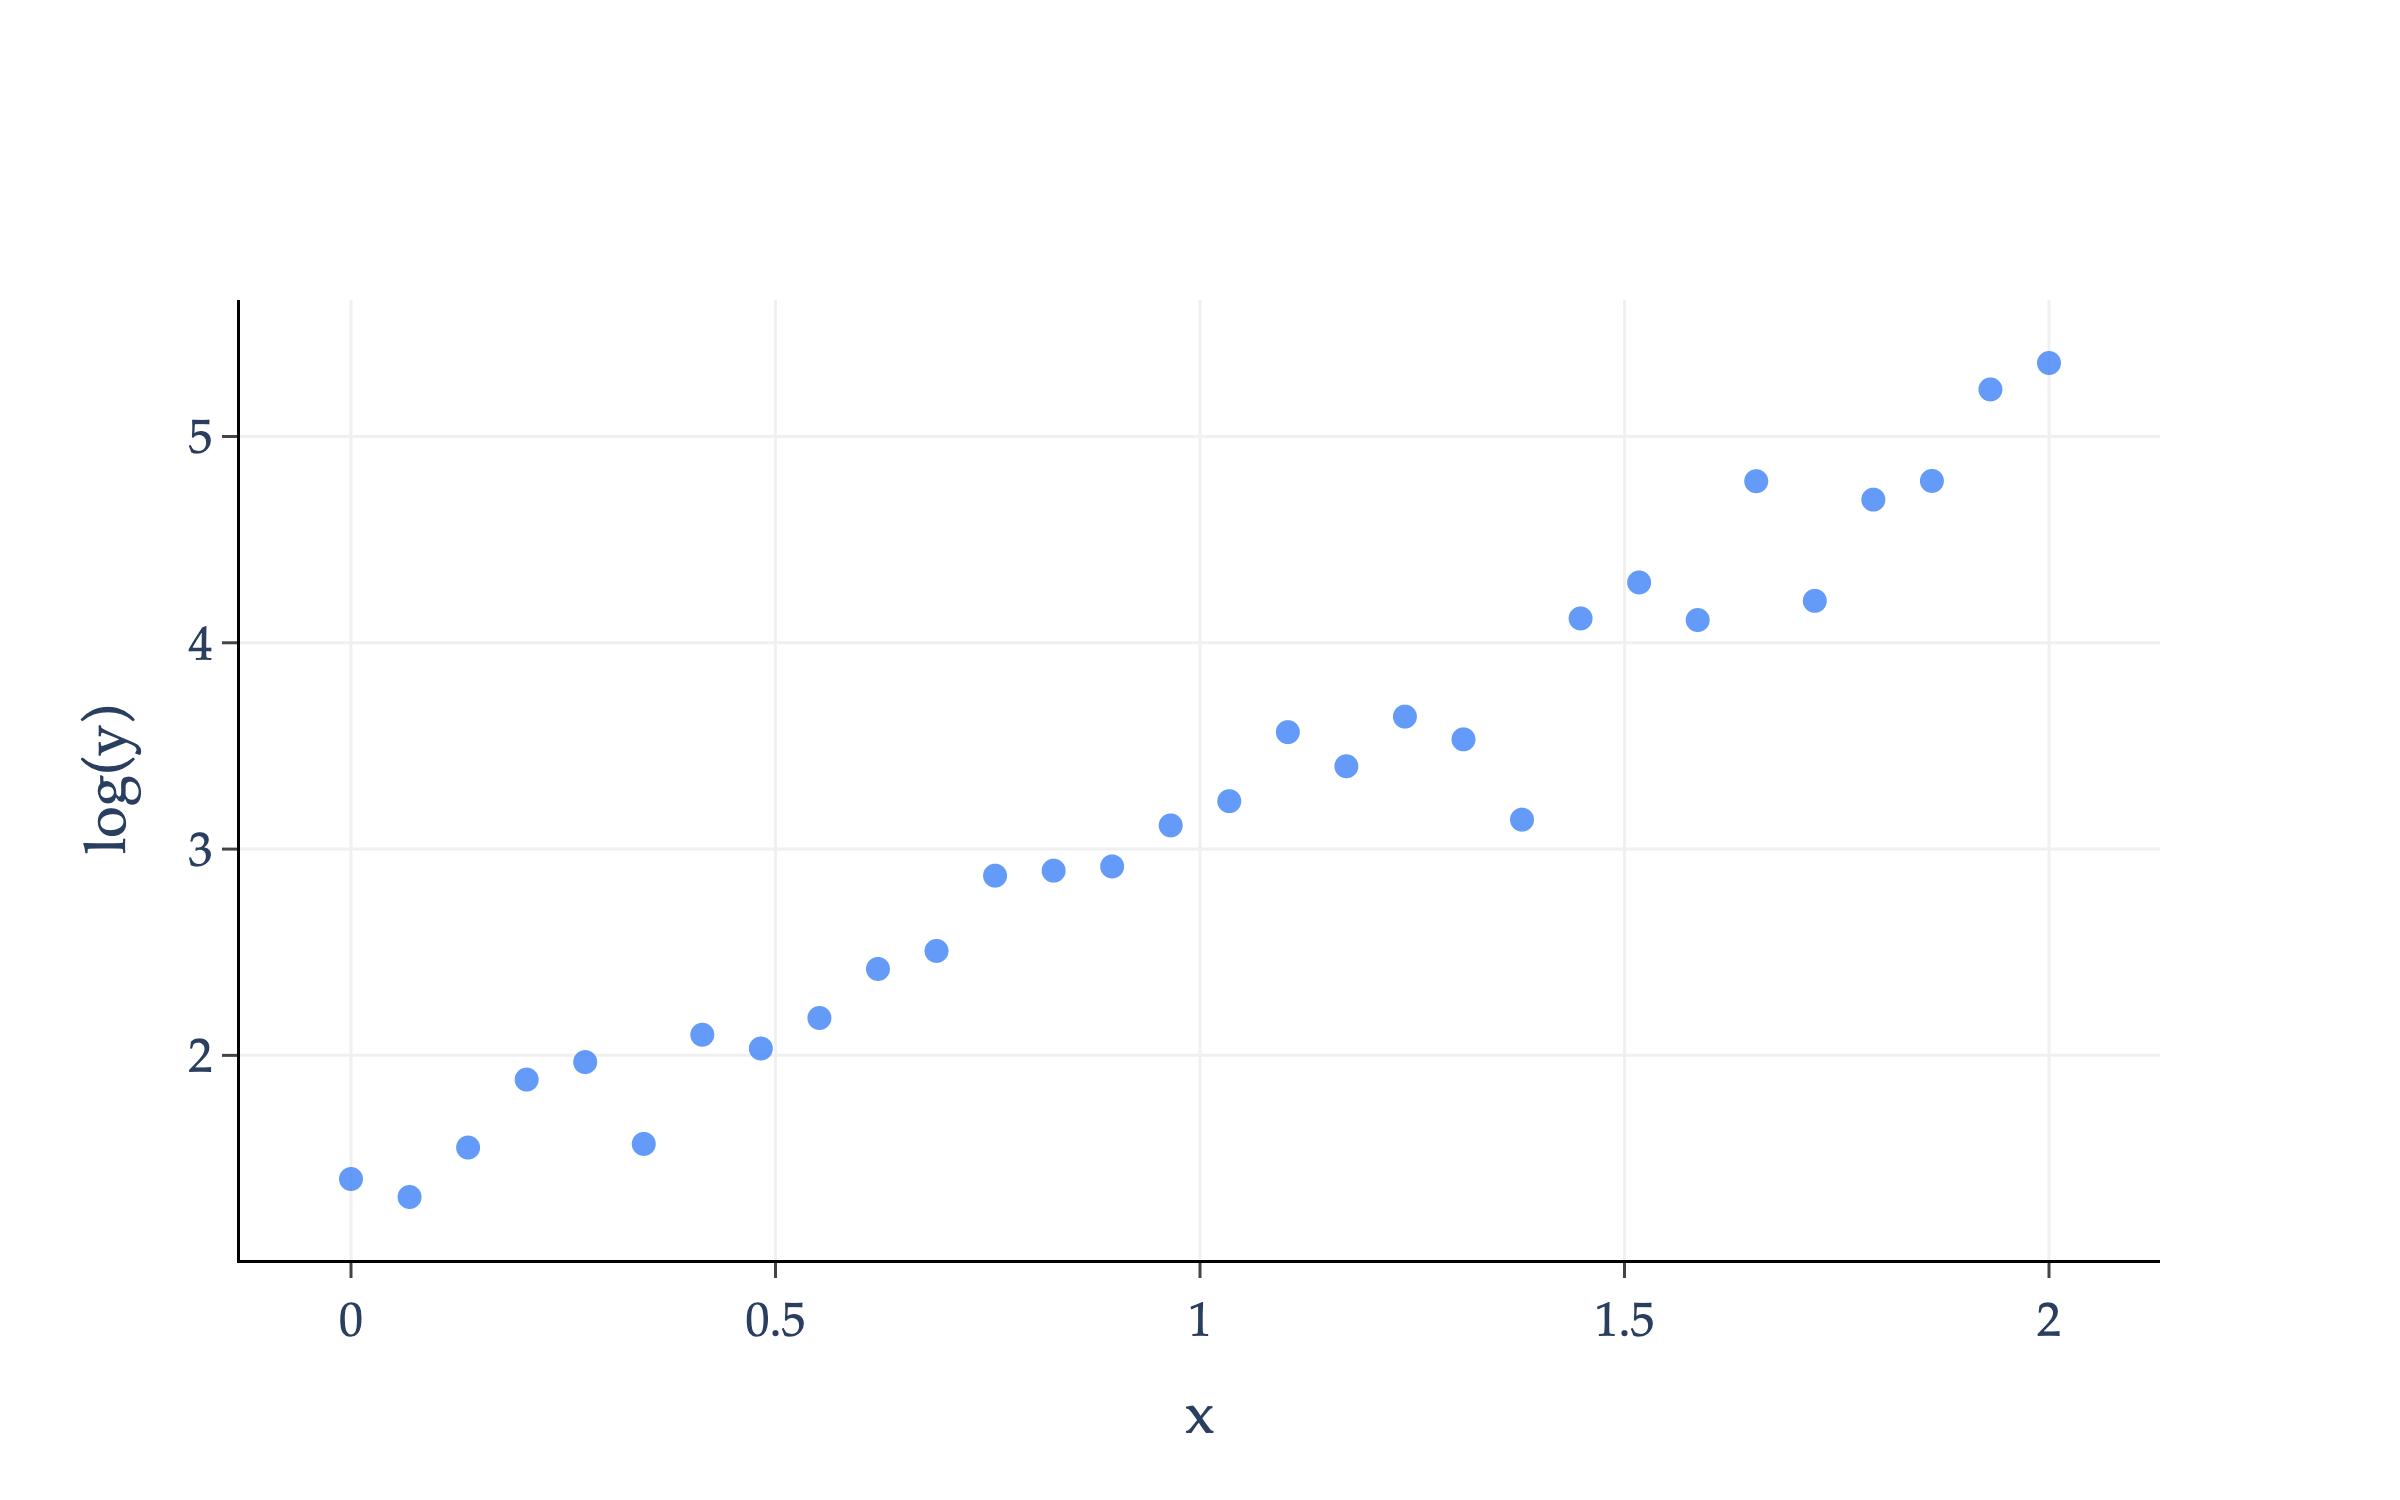

In [82]:
import numpy as np
import plotly.graph_objects as go

# Generate data
np.random.seed(0)
x = np.linspace(0, 2, 30)
y_true = 3 * np.exp(2 * x)
noise = np.random.normal(0, 0.2 * y_true, size=x.shape)
y = y_true + noise

# Take the log of each y value
log_y = np.log(y)

# Plot just the data (x vs log(y))
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=log_y, mode='markers', name='log(y)',
    marker=dict(color='#3d81f6', size=8, opacity=0.8)
))
fig.update_layout(
    xaxis_title='x',
    yaxis_title='log(y)',
    width=800,
    height=500,
    font=dict(family='Palatino, serif', size=16),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False
)
fig.update_xaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif')
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif'),
)
fig.show(renderer='png', scale=3)




<!-- If we let $t(x_i) = \log(y_i)$ and $\alpha = \log(a)$, we can write the above equation as:

$$t(x_i) = \alpha + bx_i$$

This is now a simple linear regression model, whose optimal parameters are known to us! The only thing is, in the formulas for $\alpha^*$ (the optimal intercept) and $b^*$ (the optimal slope), we'll need to use the transformed values $t(x_i)$ and $x_i$  -->

The transformed data looks roughly linear!

How does this transformation help us find $a$ and $b$? Now, instead of minimizing:

$$R_\text{sq}(a, b) = \frac{1}{n} \sum_{i=1}^n (y_i - ae^{bx_i})^2$$

I'm claiming that since $\log(y_i) \approx \log(a) + bx_i$, we can instead minimize:

$$R'_\text{sq}(a, b) = \frac{1}{n} \sum_{i=1}^n (\log(y_i) - (\underbrace{\log(a)}_{w_0} + \underbrace{b}_{w_1}x_i))^2$$

$R'_\text{sq}$ is not the derivative of $R_\text{sq}$; it is a different empirical risk function, with different optimal parameters.

That said, $R_\text{sq}'$ should look familiar: it looks remarkably similar to the mean squared error of the simple linear regression model.

Let's define $z_i = \log(y_i)$, $w_0 = \log(a)$, and $w_1 = b$. Then, we can rewrite $R'_\text{sq}$ as:

$$R'_\text{sq}(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (z_i - (w_0 + w_1 x_i))^2$$

We just spent all of [Chapter 2.3](03-finding-optimal-parameters.ipynb) finding the optimal values of $w_0^*$ and $w_1^*$ in the empirical risk function above, so the optimal values of $w_0^*$ and $w_1^*$ are well known to us!

$$w_1^* = \frac{\sum_{i=1}^n (x_i - \bar{x})(z_i - \bar{z})}{\sum_{i=1}^n (x_i - \bar{x})^2}, \qquad w_0^* = \bar{z} - w_1^* \bar{x}$$

Note that I've computed $w_0^* = 1.24$ and $w_1^* = 1.92$ using the transformed data, $(x_1, z_1), \ldots, (x_n, z_n)$. On the transformed data, this line looks like:

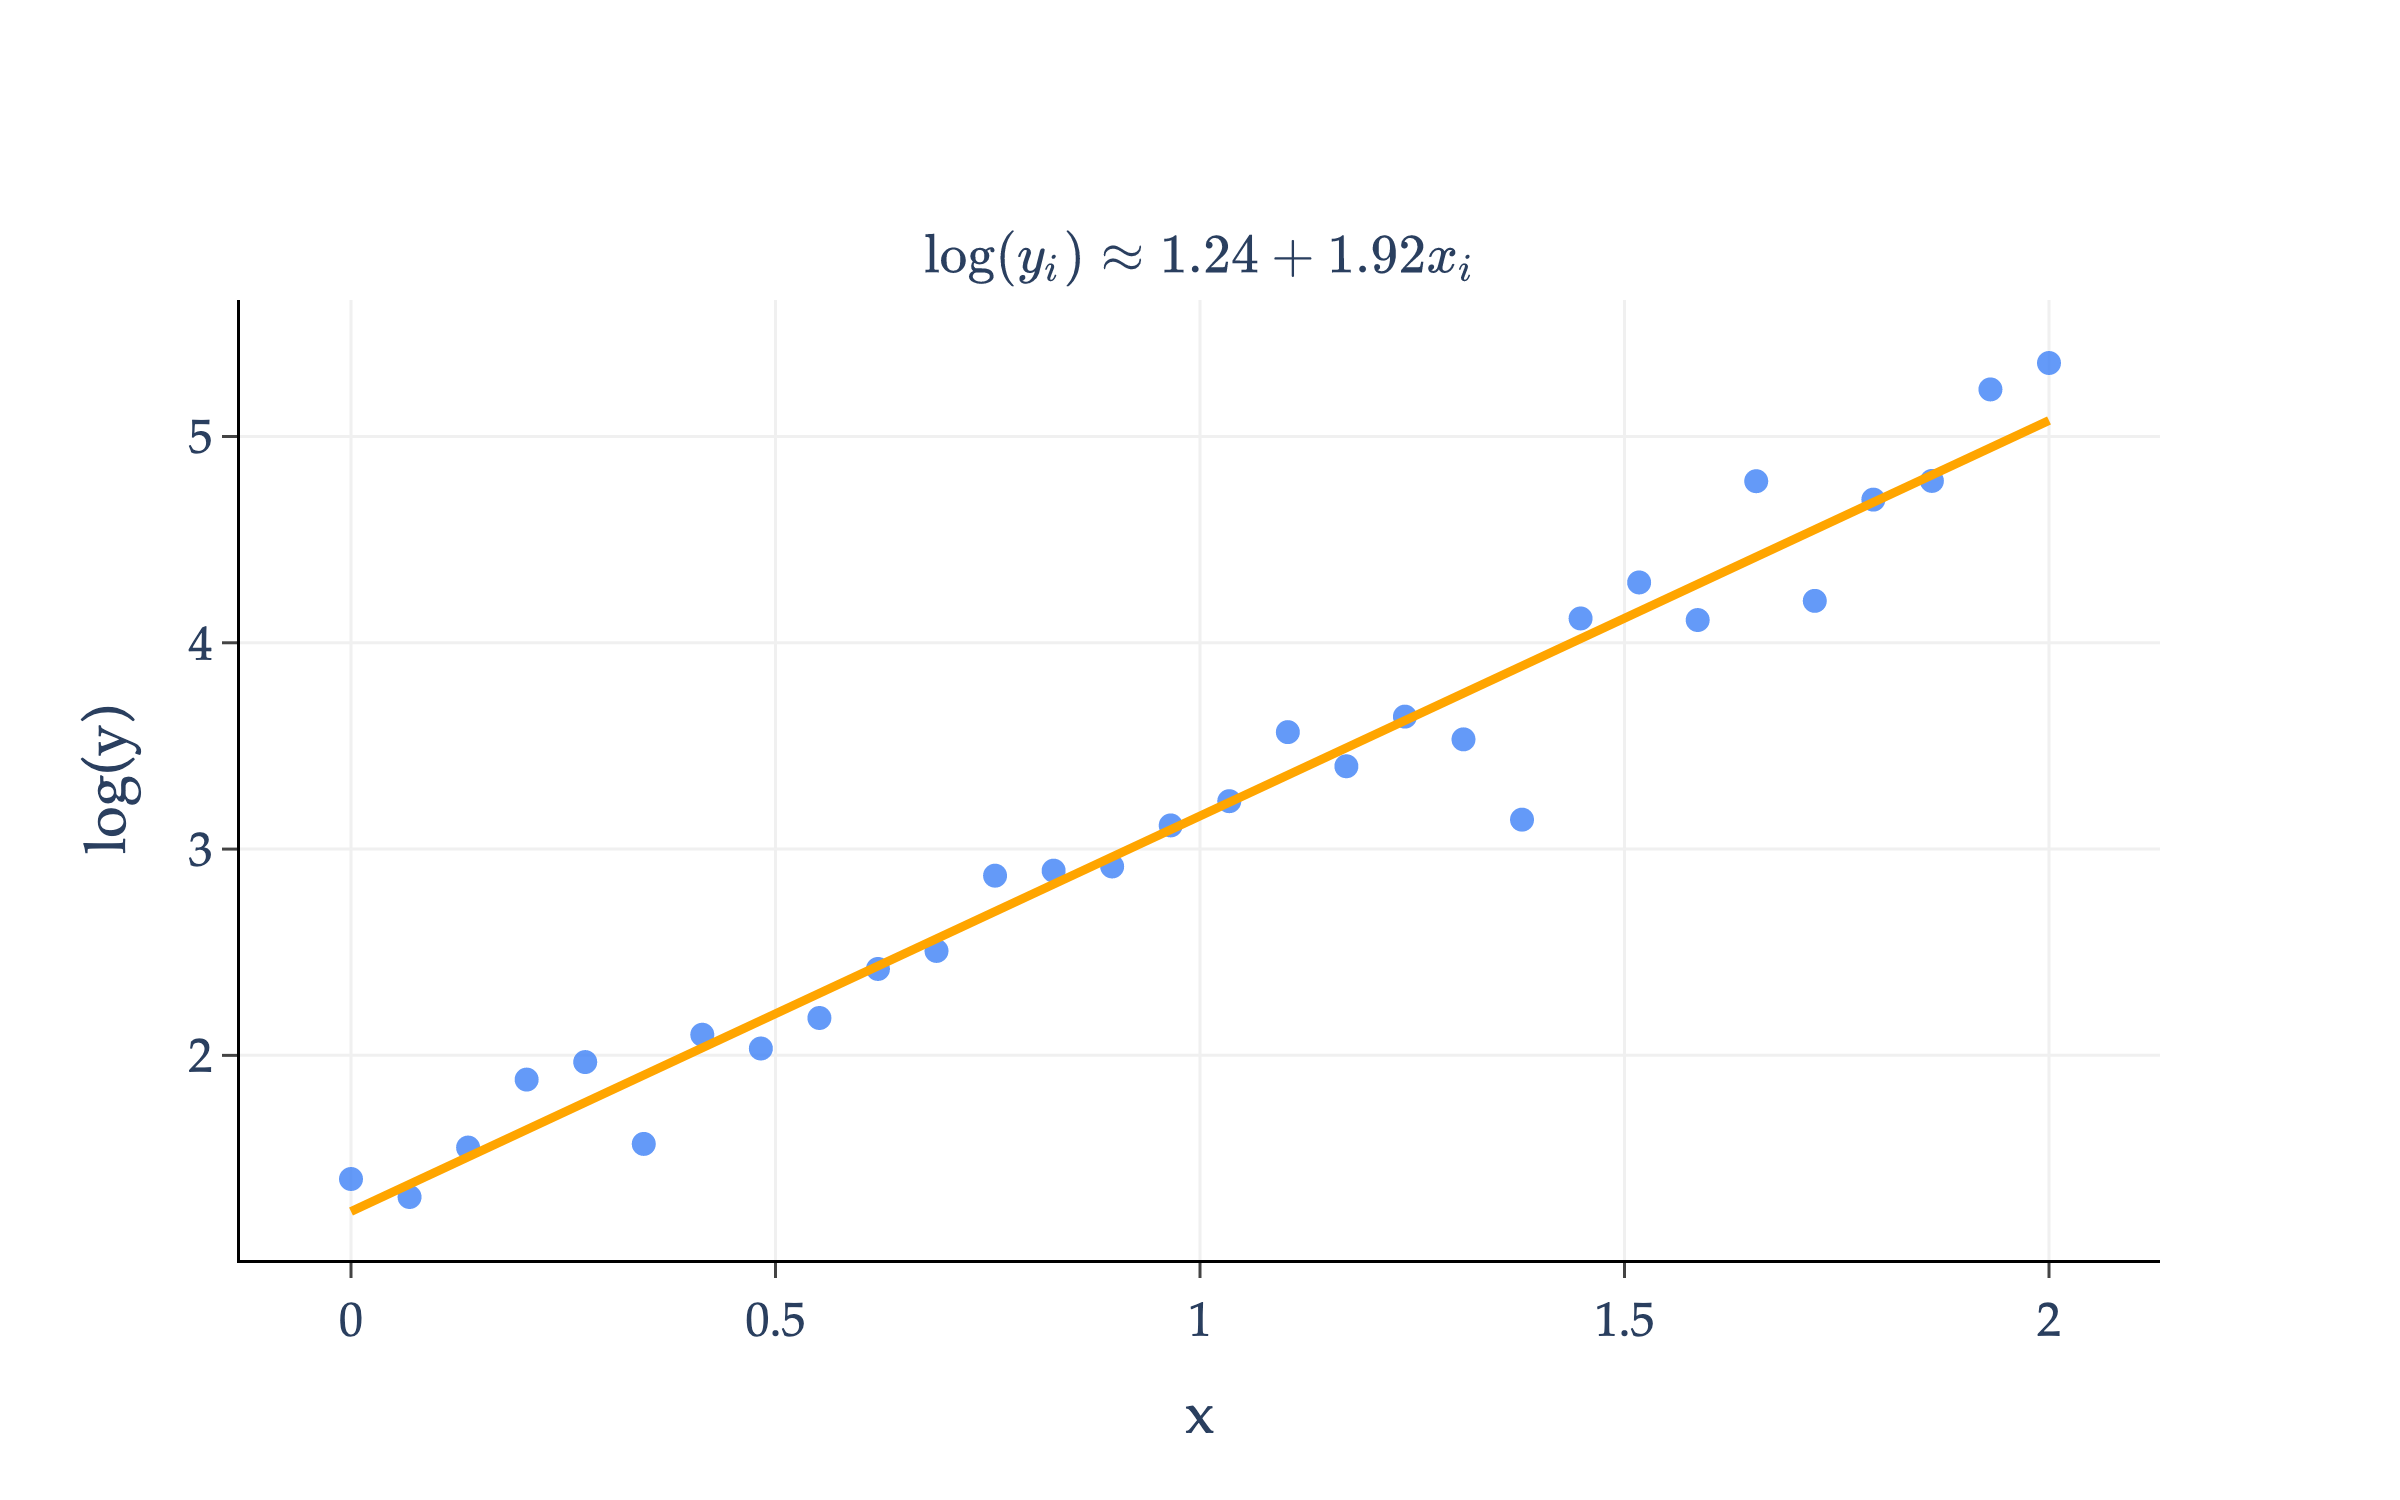

In [88]:
import numpy as np
import plotly.graph_objects as go

# Generate data
np.random.seed(0)
x = np.linspace(0, 2, 30)
y_true = 3 * np.exp(2 * x)
noise = np.random.normal(0, 0.2 * y_true, size=x.shape)
y = y_true + noise

# Take the log of each y value
log_y = np.log(y)

# Fit a line: log_y = w0 + w1 * x
w1, w0 = np.polyfit(x, log_y, 1)
line_y = w0 + w1 * x

# Plot data and fitted line
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=log_y, mode='markers', name='log(y)',
    marker=dict(color='#3d81f6', size=8, opacity=0.8)
))
fig.add_trace(go.Scatter(
    x=x, y=line_y, mode='lines', name='Fitted line',
    line=dict(color='orange', width=3)
))

# Equation string for annotation
eqn = f"$$\log(y_i) \\approx {w0:.2f} + {w1:.2f}x_i$$"

fig.update_layout(
    xaxis_title='x',
    yaxis_title='log(y)',
    width=800,
    height=500,
    font=dict(family='Palatino, serif', size=16),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    annotations=[
        dict(
            xref='paper', yref='paper',
            x=0.5, y=1.08, showarrow=False,
            text=eqn,
            font=dict(size=40, family='Palatino, serif'),
            xanchor='center'
        )
    ]
)
fig.update_xaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif')
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif'),
)
fig.show(renderer='png', scale=3)


How do we turn this back into a curve on the original data? To transform the data, we applied the following substitutions that we need to invert:

$$w_0 = \log(a) \implies a = e^{w_0} \\ b = w_1$$

So, using the above, we can find:

$$a^* = e^{w_0^*} = e^{1.24} = 3.46 \\ b^* = w_1^* = 1.92$$

So, the curve we're looking for is:

$$h(x_i) = 3.46 e^{1.92x_i}$$

And this is the equation of the orange curve I first showed you!

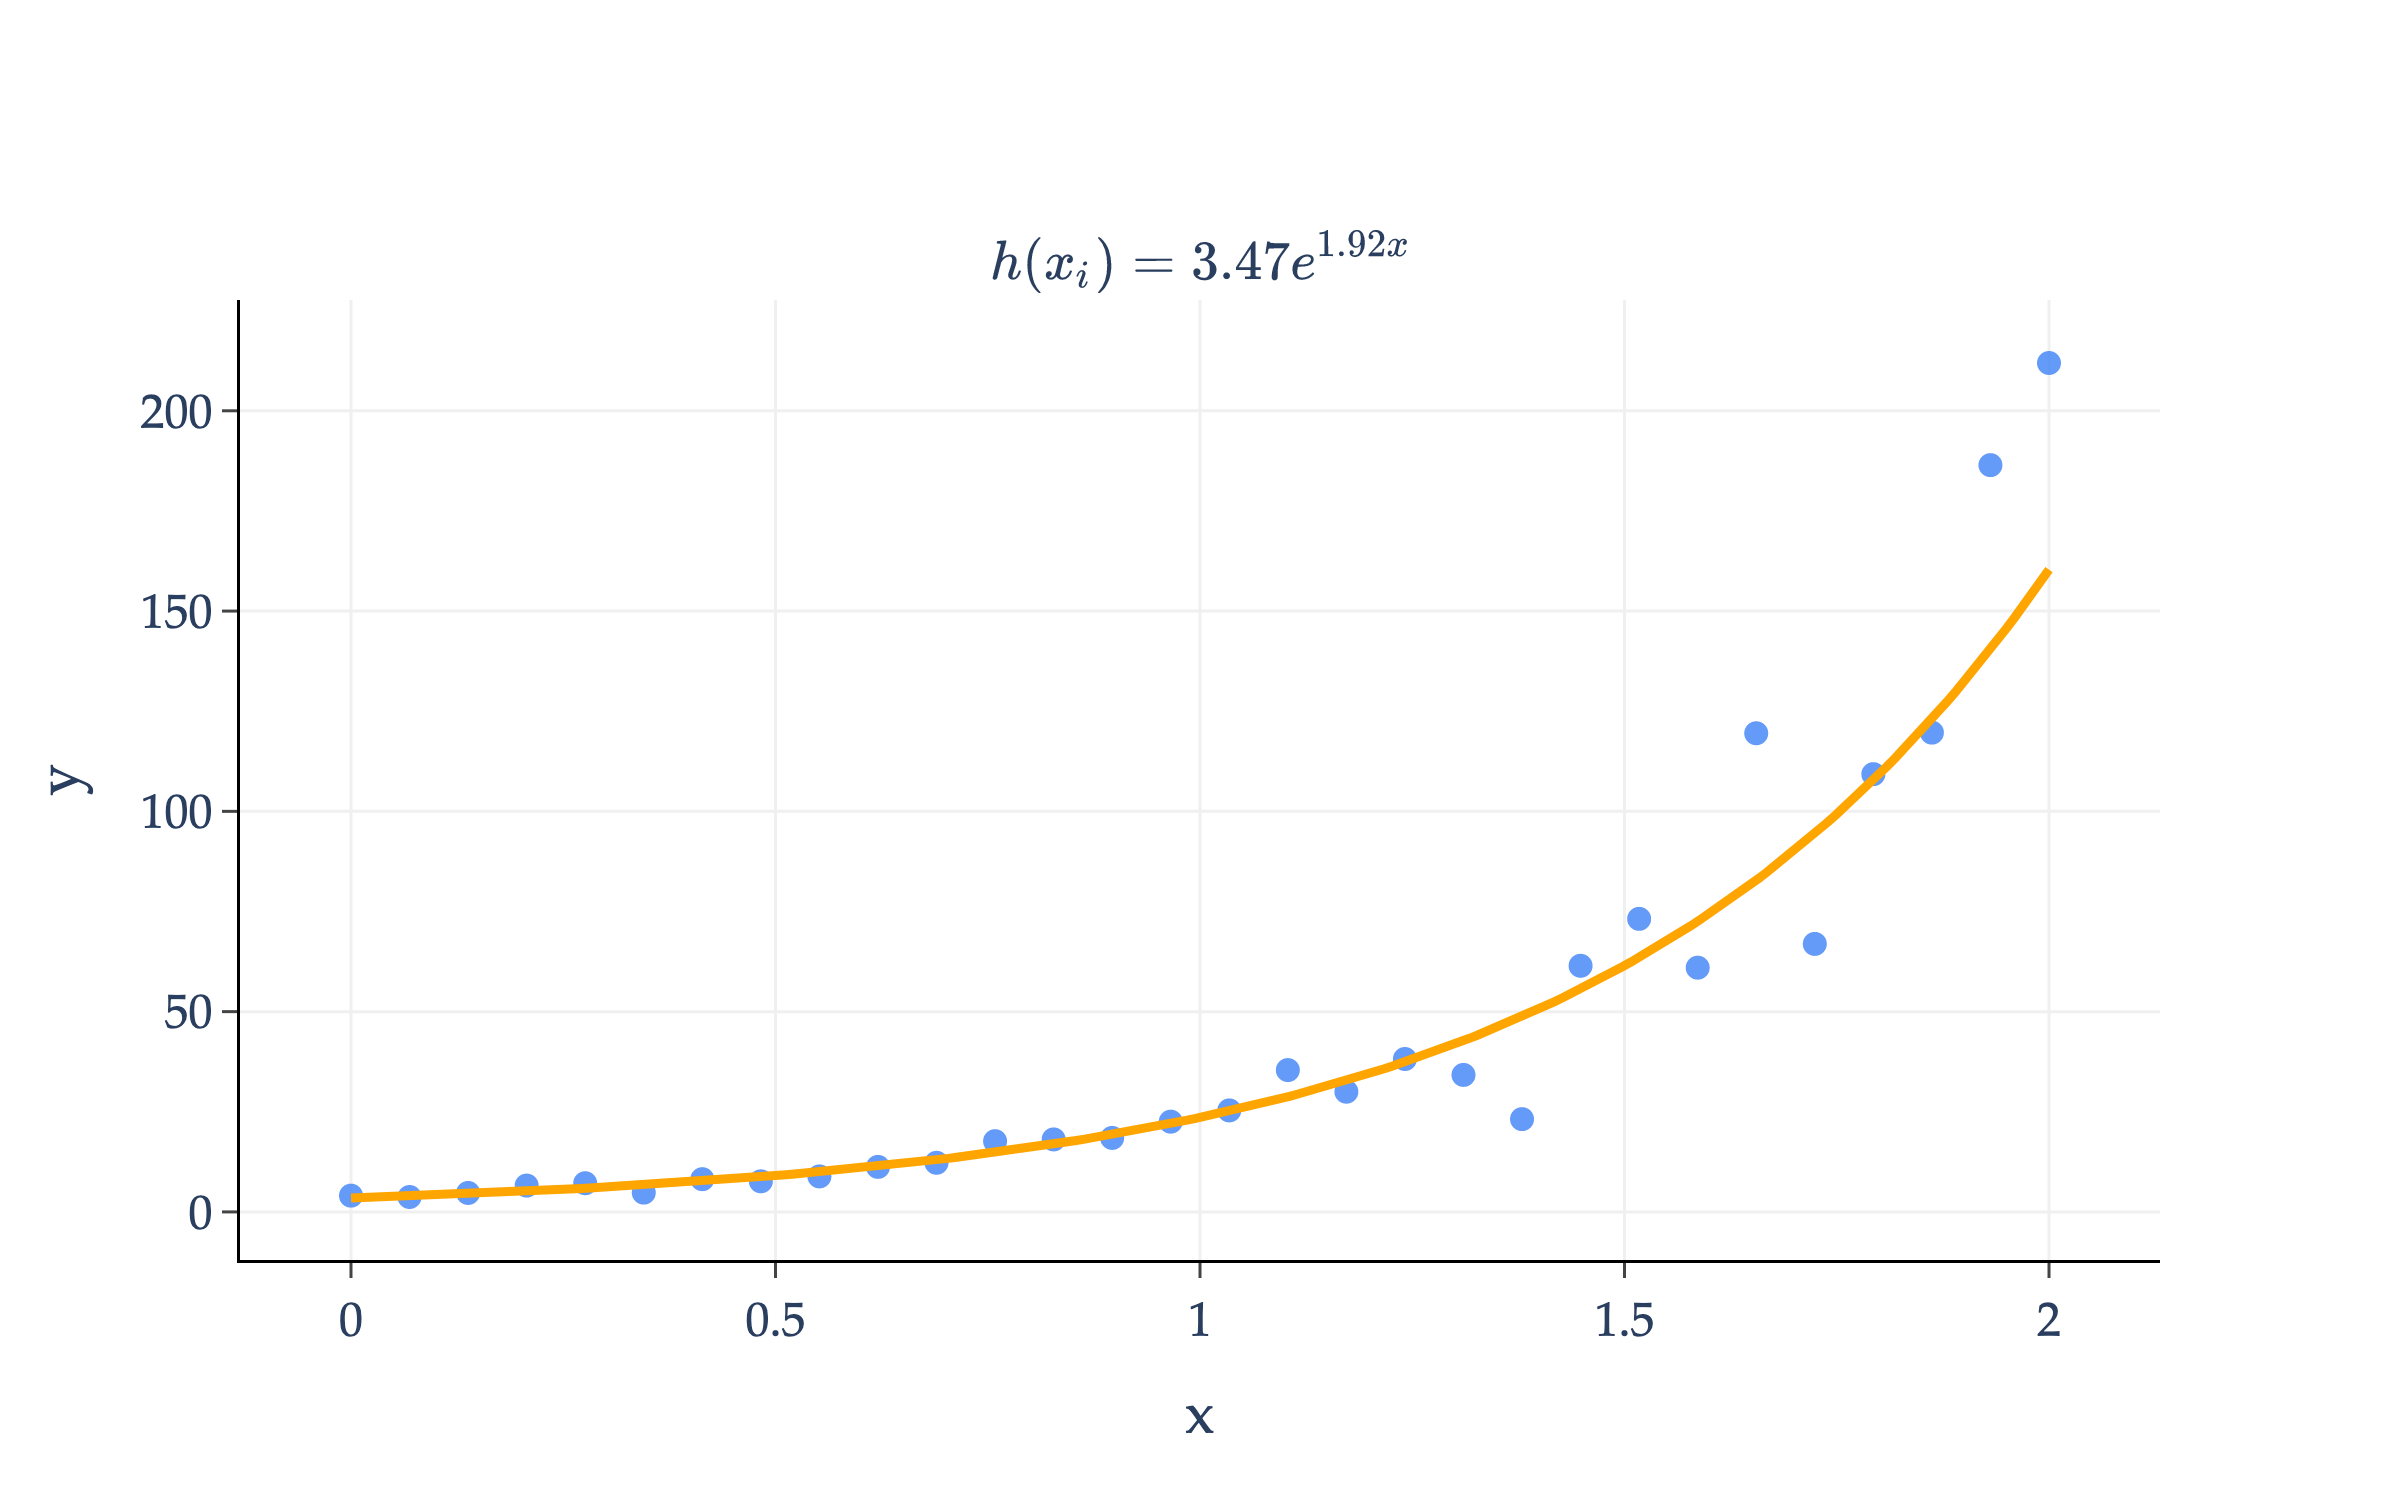

In [91]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import curve_fit

# Generate data
np.random.seed(0)
x = np.linspace(0, 2, 30)
y_true = 3 * np.exp(2 * x)
noise = np.random.normal(0, 0.2 * y_true, size=x.shape)
y = y_true + noise

# Define the model function
def exp_model(x, a, b):
    return a * np.exp(b * x)

# Fit the model to the data
z = np.log(y)
w1, w0 = np.polyfit(x, z, 1)
a_fit, b_fit = np.e ** w0, w1

# Prepare fitted curve
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = (np.e ** (w0)) * np.e ** (w1 * x_fit)#  * #exp_model(x_fit, a_fit, b_fit)

# Plot with plotly and custom style
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=y, mode='markers', name='Data',
    marker=dict(color='#3d81f6', size=8, opacity=0.8)
))
fig.add_trace(go.Scatter(
    x=x_fit, y=y_fit, mode='lines',
    name=f'Fit: y = {a_fit:.2f} e^{{{b_fit:.2f}x}}',
    line=dict(color='orange', width=3)
))
fig.update_layout(
    xaxis_title='x',
    yaxis_title='y',
    legend_title='Legend',
    width=800,
    height=500,
    font=dict(family='Palatino, serif', size=16),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    annotations=[
        dict(
            xref='paper', yref='paper',
            x=0.5, y=1.08, showarrow=False,
            text=fr'$$h(x_i) = {a_fit:.2f} e^{{{b_fit:.2f}x}}$$',
            font=dict(size=40, family='Palatino, serif'),
            xanchor='center'
        )
    ]
)
fig.update_xaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif')
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='#f0f0f0',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside',
    tickfont=dict(family='Palatino, serif'),
)
fig.show(renderer='png', scale=3)

Not every least squares problem can be reduced to the simple linear regression problem we've been studying. But, in the rare cases that it can, it's satisfying to be able to reuse our work.


---

## What's Next?

Following [Chapter 2.3](03-finding-optimal-parameters.ipynb), the next natural question to ask is, how do we use **multiple features** (input variables) to make predictions?

When we first introduced the commute times example back in [Chapter 1.2](../01_introduction_to_supervised_learning/02-squared-loss-constant-model.ipynb), we saw that the dataset we're working with has a few features beyond the departure hour.

In [19]:
df[['date', 'day', 'departure_hour', 'minutes']].head()

,date,day,departure_hour,minutes
0,5/15/2023,Mon,10.816667,68.0
1,5/16/2023,Tue,7.750000,94.0
2,5/22/2023,Mon,8.450000,63.0
3,5/23/2023,Tue,7.133333,100.0
4,5/30/2023,Tue,9.150000,69.0


Up until now, we've been using the `departure_hour` feature to predict the `minutes` column.

It would be great if we could figure out a way to use the day of the week as a feature, since our intuition tells us this might have an effect on commute times (traffic is known to be bad on Monday mornings and Friday afternoons). But, the `day` column currently contains strings, not numbers, so we'll have to think critically about how to encode this data numerically. (You'll see how to do this in a later homework.)

For now, let's extract the day of the **month** from the `date` column, and try and use `day_of_month` along with `departure_hour` as our two features.

In [23]:
df['day_of_month'] = pd.to_datetime(df['date']).dt.day
df[['departure_hour', 'day_of_month', 'minutes']].head()

,departure_hour,day_of_month,minutes
0,10.816667,15,68.0
1,7.750000,16,94.0
2,8.450000,22,63.0
3,7.133333,23,100.0
4,9.150000,30,69.0


We want to use the first two columns to predict the third. What would the hypothesis function for such a model look like? Previously, we had:

$$\underbrace{h(\text{departure hour}_i)}_{\text{predicted commute time } i} = w_0 + w_1 \cdot\text{departure hour}_i$$

Now, a linear model that involves **both** features would look like:

$$h(\text{departure hour}_i, \text{dom}_i) = w_0 + w_1 \cdot\text{departure hour}_i + w_2 \cdot\text{dom}_i$$

This is called a **multiple linear regression** model, since it uses multiple features. (To keep the equation short, I've used $\text{dom}$ to refer to the day of the month.)

The first hypothesis function, with one input variable, looked like a line in two dimensions. Our new multiple linear regression model looks like a **plane in three dimensions!**

In [54]:
from sklearn.linear_model import LinearRegression
import numpy as np
import plotly.graph_objs as go

# Prepare features and target
X = df[['departure_hour', 'day_of_month']].values
y = df['minutes'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Create grid for plane
departure_hour_range = np.linspace(df['departure_hour'].min(), df['departure_hour'].max(), 30)
day_of_month_range = np.linspace(df['day_of_month'].min(), df['day_of_month'].max(), 30)
dh_grid, dom_grid = np.meshgrid(departure_hour_range, day_of_month_range)
X_grid = np.c_[dh_grid.ravel(), dom_grid.ravel()]
y_pred_grid = model.predict(X_grid).reshape(dh_grid.shape)

# Scatter plot for data points
scatter = go.Scatter3d(
    x=df['departure_hour'],
    y=df['day_of_month'],
    z=df['minutes'],
    mode='markers',
    marker=dict(size=6, color='#3d81f6'),
    name='Data'
)

# Surface plot for regression plane
surface = go.Surface(
    x=dh_grid,
    y=dom_grid,
    z=y_pred_grid,
    colorscale='OrRd',
    opacity=0.7,
    showscale=False,
    name='Prediction Plane'
)

fig = go.Figure(data=[surface, scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='Departure Time',
        yaxis_title='Day of Month',
        zaxis_title='Commute Time (Minutes)',
        xaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        yaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        zaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        bgcolor='white'
    ),
    scene_camera=dict(
        eye=dict(x=1.5, y=-1.5, z=0.2)
    ),
    font=dict(family='Palatino, serif', size=12),
    height=500,
    width=700
)
fig.show()


In two dimensional space, a line has a constant rate of change, described by its slope.

In three dimensional space, a plane has a constant rate of change **along both the $x$ and $y$ axes**. The plane's rate of change in the $x$ (departure time) direction is given by $w_1^*$, and its rate of change in the $y$ (day of month) direction is given by $w_2^*$.

Finding the optimal values of $w_0^*$, $w_1^*$, and $w_2^*$ involves minimizing, yet again, mean squared error:

$$R_\text{sq}(w_0, w_1, w_2) = \frac{1}{n} \sum_{i=1}^n \left(y_i - (w_0 + w_1 \cdot \text{departure hour}_i + w_2 \cdot \text{dom}_i) \right)^2$$

Mean squared error here is a function of three variables, so we'd need four dimensions to visualize it, which, of course, we cannot do. To minimize $R_\text{sq}$ above, we'd need to find three partial derivatives, set them all to 0, and solve the resulting system of 3 equations and 3 unknowns.

While we _could_ do this, eventually, we'll want to consider a third feature, a fourth, and so on. In general, if we want $d$ features, we'll have $d+1$ parameters to optimize (one per feature, plus one for the intercept, $w_0$), and we'll need to solve a system of $d+1$ equations and $d+1$ unknowns to find them. Continuing this approach sounds painful.

**This** is where linear algebra comes in. Linear algebra provides a compact, efficient way to represent and manipulate systems of linear equations, and to find solutions to them.

Chapters 3 through 6 are dedicated to introducing the ideas from linear algebra that we'll need to solve this problem: **the problem of finding the parameters that minimize mean squared error for the multiple linear regression model**. It will take some time to get there, and at times, it'll seem like what we're doing is unrelated to this goal of finding optimal parameters.

But, I promise that we will close the loop in Chapter 7, when we return to multiple linear regression.